[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch08.ipynb)

Notebook Bab 8 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Reduksi dimensi memampatkan fitur. Kita bandingkan PCA (linear) dengan *autoencoder* (non-linier) untuk visualisasi, lalu mengukur efek jumlah komponen pada akurasi.

## Persiapan

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

RANDOM_STATE = 42
print('Setup selesai.')

Setup selesai.


## Section 1 - Demo: PCA vs Autoencoder pada Data Berdimensi Tinggi

## Data: citra digit 8x8 (64 dimensi)

In [2]:
digits = load_digits()
Xs = StandardScaler().fit_transform(digits.data)
y = digits.target
print('Data digits:', Xs.shape, '| jumlah kelas:', len(np.unique(y)))

Data digits: (1797, 64) | jumlah kelas: 10


## Proyeksi 2D: PCA (linear) vs autoencoder (non-linier)

*Autoencoder* dilatih untuk merekonstruksi input (`fit(Xs, Xs)`); lapisan tengah berukuran 2 menjadi ruang laten.

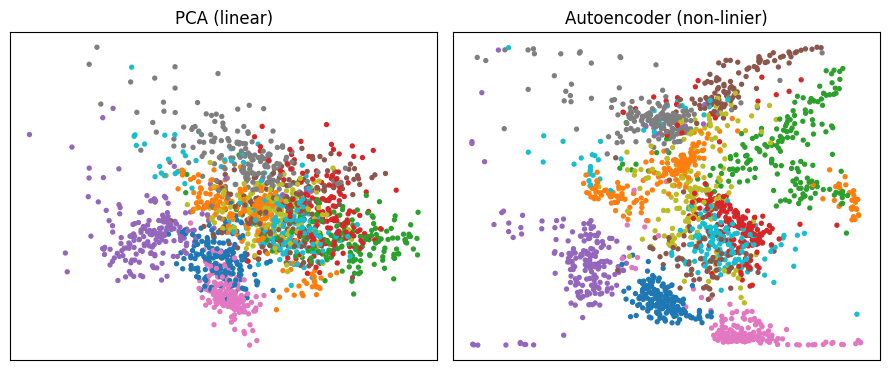

In [3]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xs)

ae = MLPRegressor(hidden_layer_sizes=(32, 2, 32), activation='tanh',
                  max_iter=800, random_state=RANDOM_STATE)
ae.fit(Xs, Xs)

def latent2d(mlp, X):
    h = np.tanh(X @ mlp.coefs_[0] + mlp.intercepts_[0])
    return np.tanh(h @ mlp.coefs_[1] + mlp.intercepts_[1])

ae2 = latent2d(ae, Xs)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for a, Z, judul in [(ax[0], pca2, 'PCA (linear)'), (ax[1], ae2, 'Autoencoder (non-linier)')]:
    a.scatter(Z[:, 0], Z[:, 1], c=y, cmap='tab10', s=8)
    a.set_title(judul); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## Efek jumlah komponen pada akurasi hilir

In [4]:
acc_full = cross_val_score(LogisticRegression(max_iter=2000), Xs, y, cv=5).mean()
acc_pca2 = cross_val_score(Pipeline([('pca', PCA(n_components=2)), ('lr', LogisticRegression(max_iter=2000))]), Xs, y, cv=5).mean()
acc_pca20 = cross_val_score(Pipeline([('pca', PCA(n_components=20)), ('lr', LogisticRegression(max_iter=2000))]), Xs, y, cv=5).mean()
print(f'64 fitur penuh   = {acc_full:.3f}')
print(f'PCA 2 komponen   = {acc_pca2:.3f}')
print(f'PCA 20 komponen  = {acc_pca20:.3f}')

64 fitur penuh   = 0.919
PCA 2 komponen   = 0.530
PCA 20 komponen  = 0.908


> 🔎 **Amati.** Di 2D, ruang laten *autoencoder* yang non-linier cenderung memisahkan kelompok digit lebih tegas daripada PCA yang hanya proyeksi linear. Dua dimensi bagus untuk visualisasi tetapi membuang banyak informasi (akurasi turun jauh); menaikkan ke 20 komponen memulihkan akurasi mendekati fitur penuh. PCA cepat dan transparan, *autoencoder* lebih ekspresif tetapi lebih mahal.

## Section 2 - Mini Project

## Soal

Anda diberi data berdimensi 30 (`load_breast_cancer`, sudah dibakukan). Targetnya klasifikasi biner.

Tugas:

1. Cari jumlah komponen PCA terkecil yang mempertahankan sekitar 95 persen *variance* (pakai `explained_variance_ratio_`).
2. Latih pengklasifikasi pada representasi PCA itu dan bandingkan dengan fitur penuh.
3. Tampilkan kurva *variance* kumulatif.

**Luaran:** kode PCA + klasifikasi, jumlah komponen 95 persen, dan 2-3 kalimat kesimpulan.

**Kriteria penilaian:** (a) PCA di dalam *pipeline* saat mengukur akurasi; (b) pemilihan komponen berdasarkan *variance*; (c) perbandingan dengan fitur penuh.

In [5]:
# DATA AWAL (jangan diubah)
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
Xb = StandardScaler().fit_transform(bc.data)
yb = bc.target
print('Data:', Xb.shape, '| kelas:', np.bincount(yb))

Data: (569, 30) | kelas: [212 357]


In [6]:
# Kerjakan di sini.
# Petunjuk: PCA().fit(Xb).explained_variance_ratio_.cumsum() untuk menemukan ambang 95 persen.
